# Cross-Border Grid Transmission — 15-Minute Data (2023–2025)

Fetches Finland cross-border electricity flows from Fingrid Open Data API.

**Corridors covered:**
- Finland ↔ Sweden (dataset 57) — largest interconnection
- Finland ← Estonia / Finland → Estonia (datasets 80 / 81) — Estlink 1 & 2
- Finland ↔ Norway (dataset 60)

Output: `grid_transmission_15min.csv`

In [1]:
import pandas as pd
import numpy as np
import requests
import time
from pathlib import Path

## 1. Configuration — fill in your API key

In [10]:
import os

# TEMPORARY — do not commit with real key
os.environ['FINGRID_API_KEY'] = 'da7df70c6609477e879ec84ae60a7caa'

API_KEY = os.environ.get('FINGRID_API_KEY')
if not API_KEY:
    raise EnvironmentError(
        'FINGRID_API_KEY environment variable is not set.\n'
        'Before launching Jupyter run:\n'
        '  PowerShell: $env:FINGRID_API_KEY = "your-key"\n'
        '  bash:       export FINGRID_API_KEY=your-key'
    )

# Fingrid dataset IDs — verified against the dataset catalog (run discovery cell to re-check)
# All four are "power measured every 15 minutes" — net flow, MW
# Sign convention: positive = Finland exports; negative = Finland imports
# (verify sign from actual data after fetching)
DATASETS = {
    'fi_ee':         55,   # Finland ↔ Estonia (Estlink 1 + 2), 15-min power
    'fi_no':         57,   # Finland ↔ Norway, 15-min measured
    'fi_se_north':   60,   # Finland ↔ Northern Sweden (SE1), 15-min power
    'fi_se_central': 61,   # Finland ↔ Central Sweden (SE3), 15-min power
}

START = '2023-01-01T00:00:00Z'
END   = '2025-12-31T23:59:59Z'
HELSINKI = 'Europe/Helsinki'

## 2. Fetch from Fingrid API

### Discover correct dataset IDs (run once to verify)

In [9]:
# Query Fingrid dataset catalog and print cross-border related datasets
# Run this cell first to verify all dataset IDs before fetching data

search_keywords = ['estonia', 'sweden', 'norway', 'russia', 'cross-border',
                   'transmission', 'exchange', 'import', 'export', 'estlink',
                   'interconnection', 'transit', 'trade']

resp = requests.get(
    'https://data.fingrid.fi/api/datasets',
    headers={'x-api-key': API_KEY},
    params={'pageSize': 500},
    timeout=30,
)
resp.raise_for_status()
catalog = resp.json().get('data', [])

print(f'Total datasets in catalog: {len(catalog)}\n')
print('--- Cross-border related datasets ---')
for ds in catalog:
    name_en = (ds.get('nameEn') or '').lower()
    if any(kw in name_en for kw in search_keywords):
        print(f"  ID {ds['id']:>5}  {ds.get('nameEn', '')}")

Total datasets in catalog: 249

--- Cross-border related datasets ---
  ID    24  Day-ahead transmission capacity SE1-FI - official
  ID    25  Day-ahead transmission capacity SE3-FI - official
  ID    26  Day-ahead transmission capacity FI-SE1 - official
  ID    27  Day-ahead transmission capacity FI-SE3 - official
  ID    30  Measured transmission of electricity in Finland from north to south
  ID    31  Commercial transmission of electricity between FI-SE1
  ID    32  Commercial transmission of electricity between FI-SE3
  ID    38  Intraday transmission capacity SE1-FI
  ID    39  Intraday transmission capacity SE3-FI
  ID    41  Planned transmission capacity FI-RUS
  ID    44  Intraday transmission capacity FI - SE1
  ID    45  Intraday transmission capacity FI-SE3
  ID    49  Bilateral trade capacity FI-RUS, unused
  ID    50  Intraday transmission capacity FI-RUS
  ID    55  Transmission of electricity between Finland and Estonia - power measured every 15 minutes
  ID    57  Tra

In [11]:
def fetch_fingrid(dataset_id: int, start: str, end: str, api_key: str) -> pd.DataFrame:
    """Fetch all pages from a Fingrid dataset with retry on 429."""
    url = f'https://data.fingrid.fi/api/datasets/{dataset_id}/data'
    headers = {'x-api-key': api_key}
    all_rows = []
    page = 1
    while True:
        for attempt in range(5):
            resp = requests.get(url, headers=headers, params={
                'startTime': start,
                'endTime':   end,
                'format':    'json',
                'pageSize':  10000,
                'page':      page,
            }, timeout=60)
            if resp.status_code == 429:
                wait = 60 * (attempt + 1)
                print(f'  429 rate limit — waiting {wait}s before retry {attempt + 1}/5 ...')
                time.sleep(wait)
                continue
            resp.raise_for_status()
            break
        else:
            raise RuntimeError(f'Dataset {dataset_id} page {page}: still 429 after 5 retries')

        body = resp.json()
        rows = body.get('data', [])
        all_rows.extend(rows)
        print(f'  page {page}: {len(rows)} rows (total so far: {len(all_rows)})')
        if len(rows) < 10000:
            break
        page += 1
        time.sleep(2)   # 2s between pages to stay under rate limit

    if not all_rows:
        return pd.DataFrame()
    df = pd.DataFrame(all_rows)
    df['datetime'] = pd.to_datetime(df['startTime'], utc=True).dt.tz_convert(HELSINKI)
    df = df.set_index('datetime')[['value']]
    df.index = df.index.tz_convert(HELSINKI)
    df = df.sort_index()
    return df

In [12]:
raw_frames = {}

for i, (name, dataset_id) in enumerate(DATASETS.items()):
    if i > 0:
        print(f'  Waiting 30s between datasets to clear rate limit ...')
        time.sleep(30)
    print(f'\nFetching {name} (dataset {dataset_id}) ...')
    df = fetch_fingrid(dataset_id, START, END, API_KEY)
    if df.empty:
        print(f'  !! ZERO ROWS for {name} (dataset {dataset_id}) — check ID in the discovery cell above !!')
        continue
    df = df.rename(columns={'value': name})
    raw_frames[name] = df
    resolution = df.index.to_series().diff().mode()[0]
    print(f'  -> {len(df)} rows  |  resolution: {resolution}  |  range: {df.index.min()} to {df.index.max()}')

print(f'\nSuccessfully fetched: {list(raw_frames.keys())}')
print(f'Missing: {[n for n in DATASETS if n not in raw_frames]}')


Fetching fi_ee (dataset 55) ...
  page 1: 10000 rows (total so far: 10000)
  page 2: 10000 rows (total so far: 20000)
  page 3: 10000 rows (total so far: 30000)
  page 4: 10000 rows (total so far: 40000)
  page 5: 10000 rows (total so far: 50000)
  page 6: 10000 rows (total so far: 60000)
  page 7: 10000 rows (total so far: 70000)
  page 8: 10000 rows (total so far: 80000)
  page 9: 10000 rows (total so far: 90000)
  page 10: 3050 rows (total so far: 93050)
  -> 93050 rows  |  resolution: 0 days 00:15:00  |  range: 2023-01-01 02:00:00+02:00 to 2026-01-01 01:30:00+02:00
  Waiting 30s between datasets to clear rate limit ...

Fetching fi_no (dataset 57) ...
  page 1: 10000 rows (total so far: 10000)
  page 2: 10000 rows (total so far: 20000)
  page 3: 10000 rows (total so far: 30000)
  page 4: 10000 rows (total so far: 40000)
  page 5: 10000 rows (total so far: 50000)
  page 6: 10000 rows (total so far: 60000)
  page 7: 10000 rows (total so far: 70000)
  page 8: 10000 rows (total so far

## 3. Combine corridors and engineer grid features

In [14]:
# Join all corridors on a common 15-min index spanning the full data range
index_15min = pd.date_range(
    start='2023-01-01 00:00',
    end='2025-12-31 23:45',
    freq='15min',
    tz=HELSINKI,
)

combined = pd.DataFrame(index=index_15min)
combined.index.name = 'datetime'

for name, df in raw_frames.items():
    # If data is hourly, resample to 15-min by forward-filling within the hour
    resampled = df.resample('15min').interpolate(method='time').reindex(index_15min)
    combined[name] = resampled[name]

print('Combined shape:', combined.shape)
print('NaN counts:')
print(combined.isna().sum())
combined.head(20)

Combined shape: (105216, 4)
NaN counts:
fi_ee            8
fi_no            8
fi_se_north      8
fi_se_central    8
dtype: int64


,fi_ee,fi_no,fi_se_north,fi_se_central
datetime,,,,
2023-01-01 00:00:00+02:00,NaN,NaN,NaN,NaN
2023-01-01 00:15:00+02:00,NaN,NaN,NaN,NaN
2023-01-01 00:30:00+02:00,NaN,NaN,NaN,NaN
2023-01-01 00:45:00+02:00,NaN,NaN,NaN,NaN
2023-01-01 01:00:00+02:00,NaN,NaN,NaN,NaN
2023-01-01 01:15:00+02:00,NaN,NaN,NaN,NaN
2023-01-01 01:30:00+02:00,NaN,NaN,NaN,NaN
2023-01-01 01:45:00+02:00,NaN,NaN,NaN,NaN
2023-01-01 02:00:00+02:00,1005.315000,-19.777990,598.426000,173.699990


In [15]:
# Derived features

# Total Sweden flow (both corridors combined)
if 'fi_se_north' in combined.columns and 'fi_se_central' in combined.columns:
    combined['fi_se_total'] = combined['fi_se_north'] + combined['fi_se_central']

# Total cross-border net flow for Finland
# Positive = Finland is a net exporter; negative = net importer
# Covers: Estonia + Norway + N.Sweden + C.Sweden
flow_cols = [c for c in ['fi_ee', 'fi_no', 'fi_se_north', 'fi_se_central'] if c in combined.columns]
if flow_cols:
    combined['fi_total_net'] = combined[flow_cols].sum(axis=1)

# Absolute flow on SE corridor — a proxy for congestion / outage
# (unusually low absolute value on normally-active corridor suggests curtailment)
if 'fi_se_total' in combined.columns:
    combined['fi_se_abs'] = combined['fi_se_total'].abs()

print('Final columns:', combined.columns.tolist())
print('Shape:', combined.shape)
combined.describe()

Final columns: ['fi_ee', 'fi_no', 'fi_se_north', 'fi_se_central', 'fi_se_total', 'fi_total_net', 'fi_se_abs']
Shape: (105216, 7)


,fi_ee,fi_no,fi_se_north,fi_se_central,fi_se_total,fi_total_net,fi_se_abs
count,105208.000000,105208.000000,105208.000000,105208.000000,105208.000000,105216.000000,105208.000000
mean,523.823271,-26.277814,-571.753335,-330.683781,-902.437117,-404.860874,1123.146847
std,368.312434,34.527565,627.985194,612.136530,993.661110,1095.245692,735.045618
min,-915.380000,-123.504000,-2245.230000,-1231.000000,-3247.080000,-3251.130000,0.030000
25%,362.177500,-50.480000,-1066.122500,-896.612500,-1699.405000,-1207.350250,493.729374
50%,366.700000,-23.680000,-711.864995,-250.513000,-954.210010,-441.807629,1036.005000
75%,937.648750,-0.190000,-90.170000,0.500000,-185.947500,340.989275,1711.119500
max,1038.230000,101.640000,1835.270000,1202.800000,2428.660000,3556.620000,3247.080000


## 4. Sanity check — look for unusual values

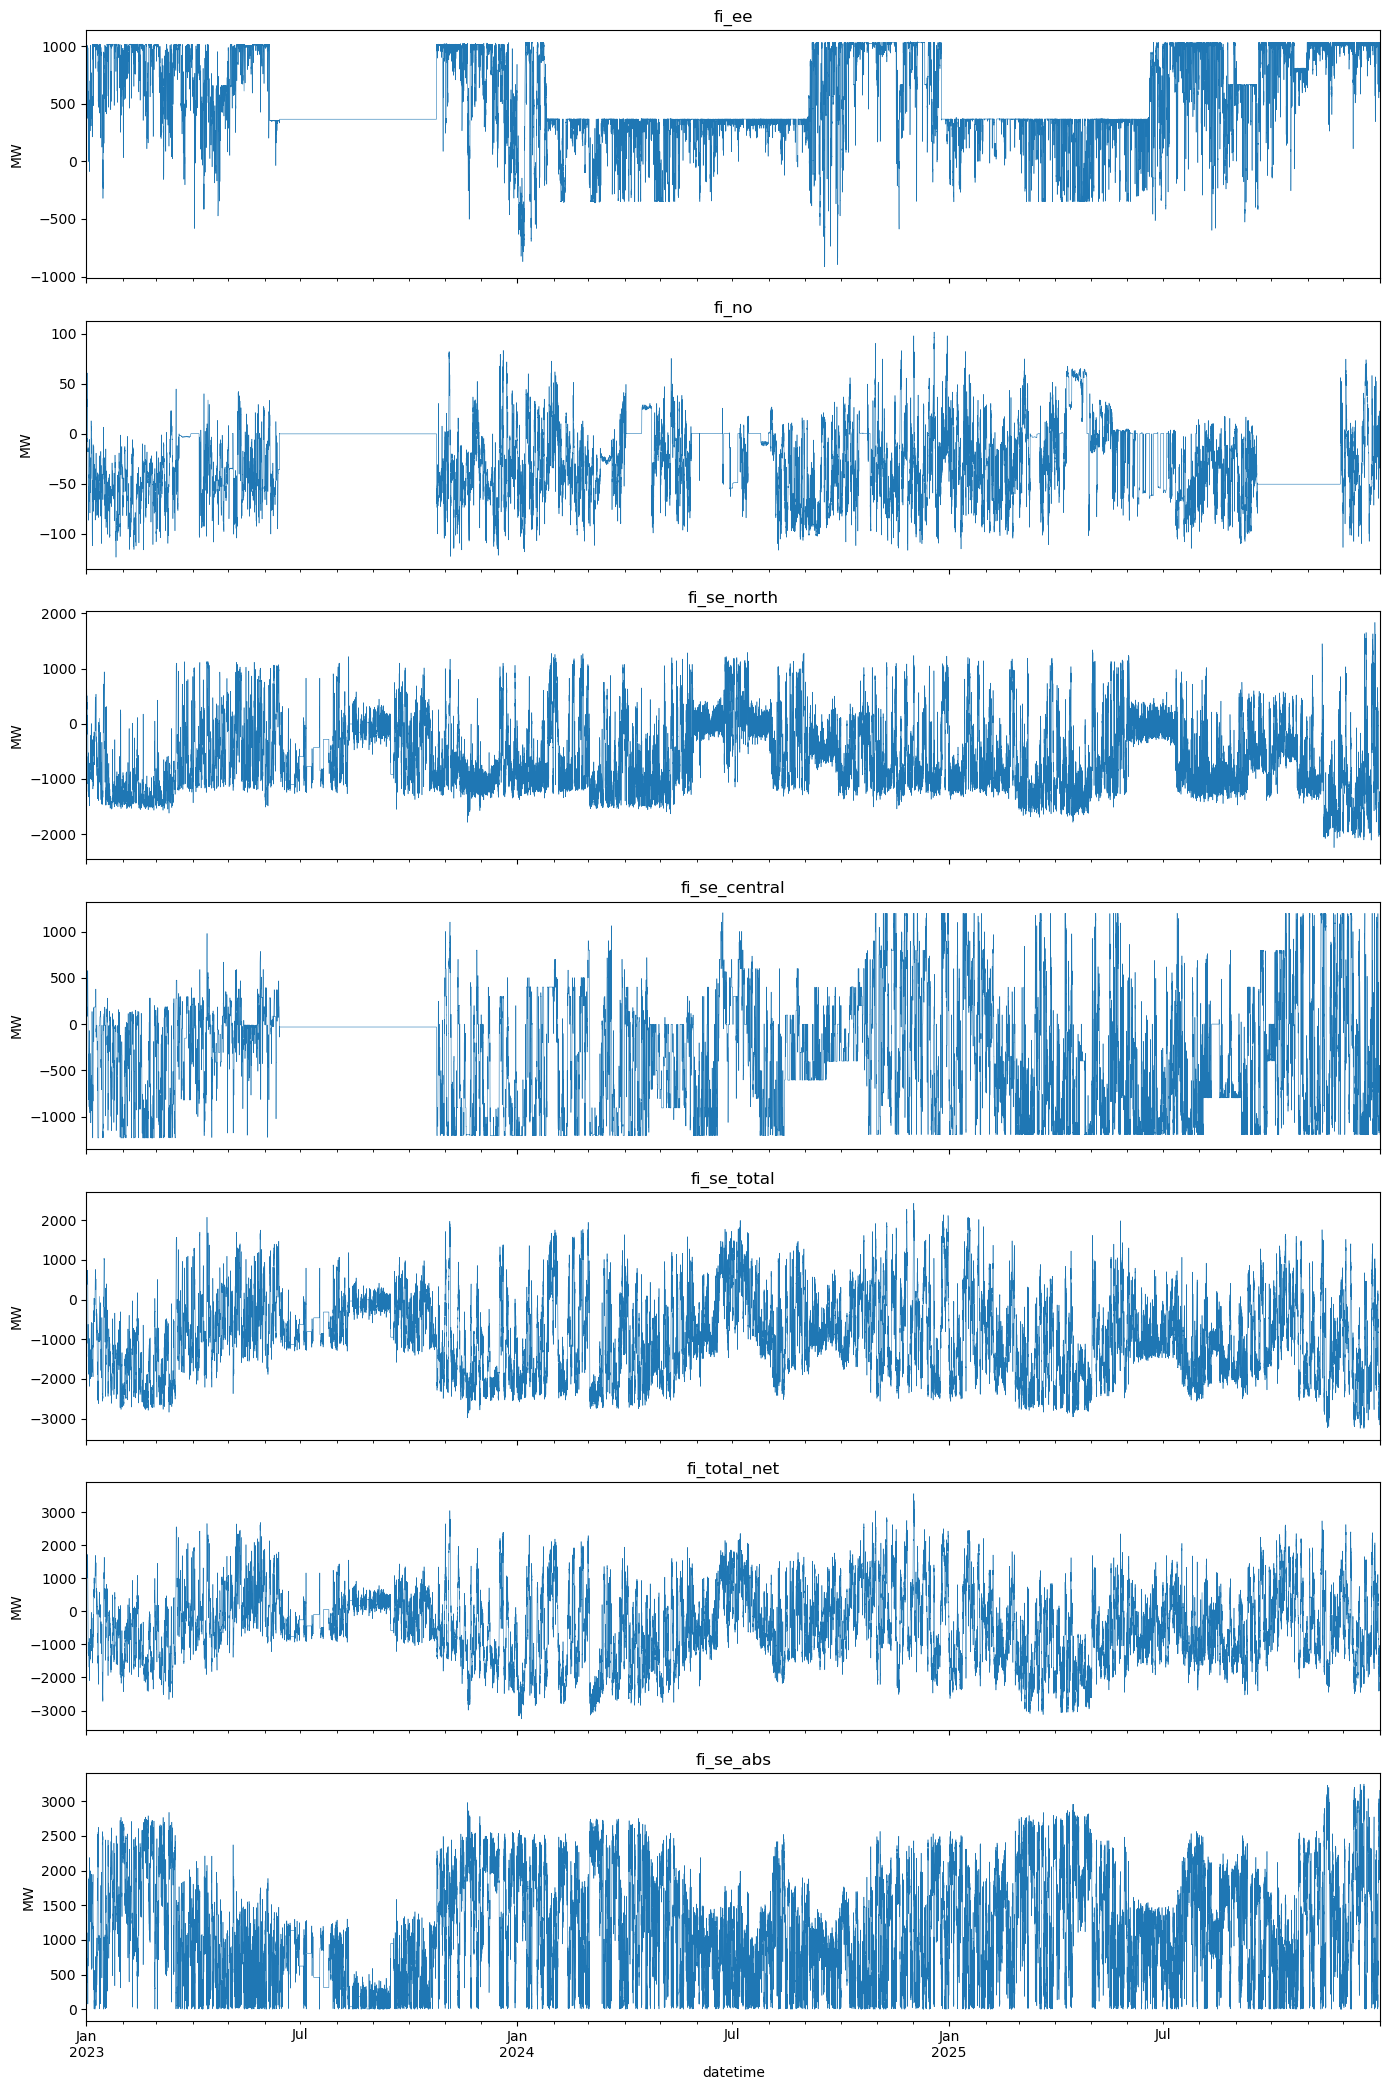

fi_ee                      min=-915  max=1038  mean=524  NaN=8
fi_no                      min=-124  max=102  mean=-26  NaN=8
fi_se_north                min=-2245  max=1835  mean=-572  NaN=8
fi_se_central              min=-1231  max=1203  mean=-331  NaN=8
fi_se_total                min=-3247  max=2429  mean=-902  NaN=8
fi_total_net               min=-3251  max=3557  mean=-405  NaN=0
fi_se_abs                  min=0  max=3247  mean=1123  NaN=8


In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(combined.columns), 1, figsize=(14, 3 * len(combined.columns)), sharex=True)
if len(combined.columns) == 1:
    axes = [axes]

for ax, col in zip(axes, combined.columns):
    combined[col].plot(ax=ax, linewidth=0.4)
    ax.set_title(col)
    ax.set_ylabel('MW')

plt.tight_layout()
plt.show()

# Print extreme values — useful for spotting data quality issues
for col in combined.columns:
    s = combined[col].dropna()
    print(f'{col:25s}  min={s.min():.0f}  max={s.max():.0f}  mean={s.mean():.0f}  NaN={combined[col].isna().sum()}')

## 5. Save

In [17]:
out_path = Path('.') / 'grid_transmission_15min.csv'
combined.to_csv(out_path, index=True)
print(f'Saved: {out_path.resolve()}')
print(f'Rows : {len(combined)}')
print(f'Range: {combined.index.min()} -> {combined.index.max()}')

Saved: C:\Users\ASUS\Documents\nordpool_electricity_price_pridiction\data\originalData\GridTransmission\grid_transmission_15min.csv
Rows : 105216
Range: 2023-01-01 00:00:00+02:00 -> 2025-12-31 23:45:00+02:00
